In [1]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import warnings
import sys
import xrft
sys.path.append("/homes/metogra/iufarias/FeedbackSubmeso/useful/")
import romspickle
import datetime
import cmocean as cm
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as PathEffects

warnings.filterwarnings("ignore")

import seawater as sw
import matplotlib.gridspec as gridspec

import statistics as stat
import scipy

from scipy.ndimage import generic_filter
from scipy.ndimage import gaussian_filter

import matplotlib as mpl


In [2]:
!rm /homes/metogra/iufarias/.cache/matplotlib/fontlist*

plt.rcParams.update({'font.size': 14})
# plt.rcParams.update({'font.weight': 'bold'})
# plt.rc('font',**{'family':'serif','serif':['Helvetica']})

plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Lucida Grande']
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['axes.linewidth'] = 1.1

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['text.usetex'] = True

props = dict(boxstyle='round', facecolor='wheat', alpha=1)


In [3]:
def along_wind_derivative(field,dx,dy,u_wind_ref,v_wind_ref,axis_x=1,axis_y=0): #field is the variable you are looking at, this could be sst,wind, du'/dr etc 
    #ref_winds are background reference
    
    d_field_dx=xr.apply_ufunc(np.gradient,field, kwargs={'axis': axis_x})/dx #np.gradient is like taking a derivative 
    d_field_dy=xr.apply_ufunc(np.gradient,field, kwargs={'axis': axis_y})/dy #the ufunc will keep the shape of the array 
    
    ws=np.sqrt(u_wind_ref**2+v_wind_ref**2) #the wind speed 

    d_field_dr= d_field_dx*(u_wind_ref/ws) + d_field_dy*(v_wind_ref/ws) #d_/dx*my average winds/my average winds + the same in the y direction 
    return d_field_dr #return this new equation 


def simple_fft_filter(FIELD,DX,DY,coord_x,coord_y,filter_lenght=5): 

    dX=float(np.diff(FIELD[coord_x]).mean()) #obtaining the average (bar) of the derivatives 
    dY=float(np.diff(FIELD[coord_y]).mean()) #obtaining the average of the derivative should be around .25


    WL=filter_lenght #applying the wavelength 

    if FIELD[coord_x].shape[0]==FIELD.shape[1]:
        nX = FIELD.T.shape[0]
        nY = FIELD.T.shape[1]
    else:
        nX = FIELD.shape[0]
        nY = FIELD.shape[1]
    mX = nX//2 #midpoints
    mY = nY//2


    # Wavelength corresponding to a given wavenumber is determined by smallest dimension
    if nX > nY:
        WN = dY*nX / WL
    else:
        WN = dX*nX / WL

    if FIELD[coord_x].shape[0]==FIELD.shape[1]:
        FT=xr.apply_ufunc(np.fft.fft2,FIELD.T)
    else:
        FT=xr.apply_ufunc(np.fft.fft2,FIELD)


    i = 0
    for j in range(1,mY+1):
        if np.sqrt( i**2 + j**2 ) > WN:
            FT[i,j] = 0
            FT[i,nY-j] = 0
    j = 0
    for i in range(1,mX+1):
        if np.sqrt( i**2 + j**2 ) > WN:
            FT[i,j] = 0
            FT[nX-i,j] = 0

    # Then take care of the remaining wavenumbers
    for i in range(1,mX+1):
        for j in range(1,mY+1):
            if np.sqrt( i**2 + j**2 ) > WN:
                FT[i,j] = 0
                FT[nX-i,j] = 0
                FT[i,nY-j] = 0
                FT[nX-i,nY-j] = 0
    if FIELD[coord_x].shape[0]==FIELD.shape[1]:
        T_filt = xr.apply_ufunc(np.fft.ifft2,FT).T
    else:
        T_filt = xr.apply_ufunc(np.fft.ifft2,FT)

    T_filt = T_filt.real
    return T_filt

## Reading WRF(3D)

In [4]:
# chunks={'time_counter':1}

# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrf_3D_Y2012M*DAY.nc',data_vars='minimal')
# vartw=xr.open_mfdataset('/data/pacific/lrenault/SASI/SMTH/WRF/wrf_3D_Y2012M*DAY.nc',data_vars='minimal')

varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrfout_Y2012M*.nc',data_vars='minimal')
vartw=xr.open_mfdataset('/data/pacific/lrenault/SASI/SMTH/WRF/wrfout_Y2012M*.nc',data_vars='minimal')


## Separating variables

In [5]:
xcoast=215

In [6]:
w_full=varfw.W.compute().isel(x_grid_M=slice(0,xcoast))
u_full_g=varfw.U.isel(lev_M=slice(0,12)).compute()
v_full_g=varfw.V.isel(lev_M=slice(0,12)).compute()

u_full=((u_full_g[:,:,:,1:] + u_full_g[:,:,:,:-1])/2).isel(x_grid_U=slice(0,xcoast))
v_full=((v_full_g[:,:,1:,:] + v_full_g[:,:,:-1,:])/2).isel(x_grid_V=slice(0,xcoast))

pbl_full=varfw.PBLH.compute().isel(x_grid_M=slice(0,xcoast))
sst_full=varfw.SST.compute().isel(x_grid_M=slice(0,xcoast))

In [7]:
Z=((varfw['PH'] + varfw['PHB'])/9.8).isel(x_grid_M=slice(0,xcoast)).compute()
Z_m=Z[:,1:,:,:].data/2 + Z[:,:-1,:,:]/2


In [8]:
w_smth=vartw.W.compute().isel(x_grid_M=slice(0,xcoast))
u_smth_g=vartw.U.isel(lev_M=slice(0,12)).compute()
v_smth_g=vartw.V.isel(lev_M=slice(0,12)).compute()

u_smth=((u_smth_g[:,:,:,1:] + u_smth_g[:,:,:,:-1])/2).isel(x_grid_U=slice(0,xcoast))
v_smth=((v_smth_g[:,:,1:,:] + v_smth_g[:,:,:-1,:])/2).isel(x_grid_V=slice(0,xcoast))

pbl_smth=vartw.PBLH.compute().isel(x_grid_M=slice(0,xcoast))
sst_smth=vartw.SST.compute().isel(x_grid_M=slice(0,xcoast))

## Smoothing fields

In [38]:
gaussian_filter?

Signature:
gaussian_filter(
    input,
    sigma,
    order=0,
    output=None,
    mode='reflect',
    cval=0.0,
    truncate=4.0,
)
Docstring:
Multidimensional Gaussian filter.

Parameters
----------
input : array_like
    The input array.
sigma : scalar or sequence of scalars
    Standard deviation for Gaussian kernel. The standard
    deviations of the Gaussian filter are given for each axis as a
    sequence, or as a single number, in which case it is equal for
    all axes.
order : int or sequence of ints, optional
    The order of the filter along each axis is given as a sequence
    of integers, or as a single number. An order of 0 corresponds
    to convolution with a Gaussian kernel. A positive order
    corresponds to convolution with that derivative of a Gaussian.
output : array or dtype, optional
    The array in which to place the output, or the dtype of the
    returned array. By default an array of the same dtype as input
    will be created.
mode : str or sequence, opt

In [48]:
# wfl=50




# day=0
day=slice(0,213)
levm=0


wfl=1/(150)

'FULL'
sst_mean_full=sst_full.isel(time_counter=day).copy(data=
                            gaussian_filter([sst_full_day.values for sst_full_day in sst_full.isel(time_counter=day)],sigma=1/(2*np.pi*wfl) ).data)

pbl_mean_full=pbl_full.isel(time_counter=day).copy(data=
                            gaussian_filter([pbl_full_day.values for pbl_full_day in pbl_full.isel(time_counter=day)],sigma=1/(2*np.pi*wfl) ).data)

u_mean_full=u_full.isel(time_counter=day,lev_M=levm).copy(data=
                            gaussian_filter([u_full_day.values for u_full_day in u_full.isel(time_counter=day,lev_M=levm)],sigma=1/(2*np.pi*wfl) ).data)

v_mean_full=v_full.isel(time_counter=day,lev_M=levm).copy(data=
                            gaussian_filter([v_full_day.values for v_full_day in v_full.isel(time_counter=day,lev_M=levm)],sigma=1/(2*np.pi*wfl) ).data)


# sst_mean_full=simple_fft_filter(sst_full.isel(time_counter=day),
#                                 DX=dx,DY=dy,coord_x='x_grid_M',coord_y='y_grid_M',filter_lenght=wfl)
# pbl_mean_full=simple_fft_filter(pbl_full.isel(time_counter=day),
#                                 DX=dx,DY=dy,coord_x='x_grid_M',coord_y='y_grid_M',filter_lenght=wfl)
# u_mean_full=simple_fft_filter(u_full.isel(time_counter=day,lev_M=levm),
#                                 DX=dx,DY=dy,coord_x='x_grid_U',coord_y='y_grid_U',filter_lenght=wfl)
# v_mean_full=simple_fft_filter(v_full.isel(time_counter=day,lev_M=levm),
#                                 DX=dx,DY=dy,coord_x='x_grid_V',coord_y='y_grid_V',filter_lenght=wfl)

wind_mean_full=np.sqrt(u_mean_full**2 + v_mean_full.values**2)


'SMTH'
sst_mean_smth=sst_smth.isel(time_counter=day).copy(data=
                            gaussian_filter([sst_smth_day.values for sst_smth_day in sst_smth.isel(time_counter=day)],sigma=1/(2*np.pi*wfl) ).data)

pbl_mean_smth=pbl_smth.isel(time_counter=day).copy(data=
                            gaussian_filter([pbl_smth_day.values for pbl_smth_day in pbl_smth.isel(time_counter=day)],sigma=1/(2*np.pi*wfl) ).data)

u_mean_smth=u_smth.isel(time_counter=day,lev_M=levm).copy(data=
                            gaussian_filter([u_smth_day.values for u_smth_day in u_full.isel(time_counter=day,lev_M=levm)],sigma=1/(2*np.pi*wfl) ).data)

v_mean_smth=v_smth.isel(time_counter=day,lev_M=levm).copy(data=
                            gaussian_filter([v_smth_day.values for v_smth_day in v_full.isel(time_counter=day,lev_M=levm)],sigma=1/(2*np.pi*wfl) ).data)


wind_mean_smth=np.sqrt(u_mean_smth**2 + v_mean_smth.values**2)




### Anomalies

In [50]:
sst_anom_full=sst_full.isel(time_counter=day)-sst_mean_full
u_anom_full=u_full.isel(time_counter=day,lev_M=levm)-u_mean_full
v_anom_full=v_full.isel(time_counter=day,lev_M=levm)-v_mean_full

# wind_anom_full=np.sqrt(u_anom_full**2 + v_anom_full.values**2)

pbl_anom_full=pbl_full.isel(time_counter=day).copy(data=(pbl_full.isel(time_counter=day)-pbl_mean_full.values))

wind_anom_full=np.sqrt(u_full.isel(time_counter=day,lev_M=levm).values**2 + v_full.isel(time_counter=day,lev_M=levm)**2).values - wind_mean_full




sst_anom_smth=sst_smth.isel(time_counter=day)-sst_mean_smth
u_anom_smth=u_smth.isel(time_counter=day,lev_M=levm)-u_mean_smth
v_anom_smth=v_smth.isel(time_counter=day,lev_M=levm)-v_mean_smth

# wind_anom_full=np.sqrt(u_anom_full**2 + v_anom_full.values**2)

pbl_anom_smth=pbl_smth.isel(time_counter=day).copy(data=(pbl_smth.isel(time_counter=day)-pbl_mean_smth.values))

wind_anom_smth=np.sqrt(u_smth.isel(time_counter=day,lev_M=levm).values**2 + v_smth.isel(time_counter=day,lev_M=levm)**2).values - wind_mean_smth

## Normal correlation

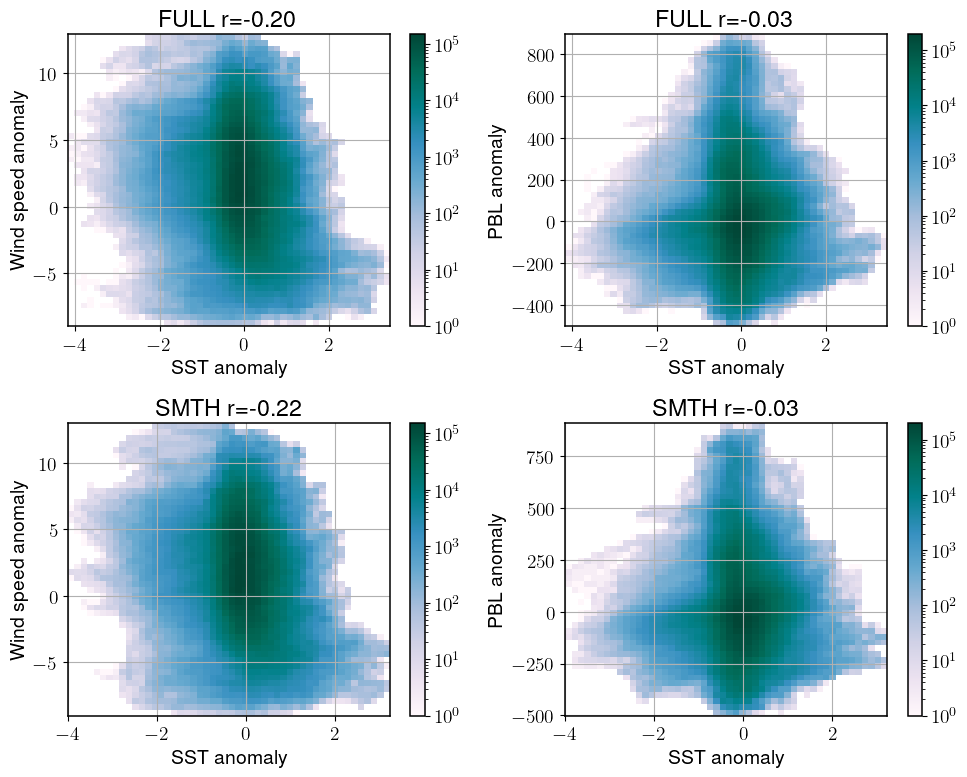

In [51]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)

plt.hist2d(np.ravel(sst_anom_full),np.ravel(wind_anom_full),cmap='PuBuGn',norm=mpl.colors.LogNorm(),bins=50)
plt.colorbar()
plt.title('FULL r='+ '{0:.2f}'.format(np.corrcoef(np.ravel(sst_anom_full.values),np.ravel(wind_anom_full.values))[0][1]))
plt.grid()
plt.xlabel('SST anomaly')
plt.ylabel('Wind speed anomaly')
# plt.ylim(-1.5,1.5)
# plt.xlim(-0.5,0.5)

plt.subplot(2,2,2)
plt.hist2d(np.ravel(sst_anom_full),np.ravel(pbl_anom_full),cmap='PuBuGn',norm=mpl.colors.LogNorm(),bins=50)
plt.colorbar()
plt.title('FULL r='+ '{0:.2f}'.format(np.corrcoef(np.ravel(sst_anom_full.values),
                                                      np.ravel(pbl_anom_full.values))[0][1]))
plt.grid()
plt.xlabel('SST anomaly')
plt.ylabel('PBL anomaly')
# plt.ylim(-1.5,1.5)
# plt.xlim(-0.5,0.5)




plt.subplot(2,2,3)

plt.hist2d(np.ravel(sst_anom_smth),np.ravel(wind_anom_smth),cmap='PuBuGn',norm=mpl.colors.LogNorm(),bins=50)
plt.colorbar()
plt.title('SMTH r='+ '{0:.2f}'.format(np.corrcoef(np.ravel(sst_anom_smth.values),np.ravel(wind_anom_smth.values))[0][1]))
plt.grid()
plt.xlabel('SST anomaly')
plt.ylabel('Wind speed anomaly')
# plt.ylim(-1.5,1.5)
# plt.xlim(-0.5,0.5)

plt.subplot(2,2,4)
plt.hist2d(np.ravel(sst_anom_smth),np.ravel(pbl_anom_smth),cmap='PuBuGn',norm=mpl.colors.LogNorm(),bins=50)
plt.colorbar()
plt.title('SMTH r='+ '{0:.2f}'.format(np.corrcoef(np.ravel(sst_anom_smth.values),
                                                      np.ravel(pbl_anom_smth.values))[0][1]))
plt.grid()
plt.xlabel('SST anomaly')
plt.ylabel('PBL anomaly')
# plt.ylim(-1.5,1.5)
# plt.xlim(-0.5,0.5)


plt.tight_layout()


## Gradient method

In [149]:
g_wdw=100
wfl=1/(2*np.pi*(1/g_wdw))
print('~' + '{0}'.format(g_wdw*2) + 'km cutoff')



u_mean_full=u_full.isel(time_counter=day,lev_M=levm).copy(data=
                            gaussian_filter([u_full_day.values for u_full_day in u_full.isel(time_counter=day,lev_M=levm)],sigma=wfl ).data)

v_mean_full=v_full.isel(time_counter=day,lev_M=levm).copy(data=
                            gaussian_filter([v_full_day.values for v_full_day in v_full.isel(time_counter=day,lev_M=levm)],sigma=wfl ).data)

u_mean_smth=u_smth.isel(time_counter=day,lev_M=levm).copy(data=
                            gaussian_filter([u_smth_day.values for u_smth_day in u_smth.isel(time_counter=day,lev_M=levm)],sigma=wfl ).data)

v_mean_smth=v_smth.isel(time_counter=day,lev_M=levm).copy(data=
                            gaussian_filter([v_smth_day.values for v_smth_day in v_smth.isel(time_counter=day,lev_M=levm)],sigma=wfl ).data)

wind_mean_full=np.sqrt(u_mean_full**2 + v_mean_full.values**2)
wind_mean_smth=np.sqrt(u_mean_smth**2 + v_mean_smth.values**2)


u_anom_full=u_full.isel(time_counter=day,lev_M=levm)-u_mean_full
v_anom_full=v_full.isel(time_counter=day,lev_M=levm)-v_mean_full


ur_anom_full= u_anom_full.copy(data=((u_anom_full*(u_mean_full.values) + v_anom_full.values*(v_mean_full.values))/(wind_mean_full.values)))
ur_anom_smth= u_anom_smth.copy(data=((u_anom_smth*(u_mean_smth.values) + v_anom_smth.values*(v_mean_smth.values))/(wind_mean_smth.values)))


'FULL'
sst_mean_full=sst_full.isel(time_counter=day).copy(data=
                            gaussian_filter([sst_full_day.values for sst_full_day in sst_full.isel(time_counter=day)],sigma=wfl ).data)

pbl_mean_full=pbl_full.isel(time_counter=day).copy(data=
                            gaussian_filter([pbl_full_day.values for pbl_full_day in pbl_full.isel(time_counter=day)],sigma=wfl ).data)

'SMTH'
sst_mean_smth=sst_smth.isel(time_counter=day).copy(data=
                            gaussian_filter([sst_smth_day.values for sst_smth_day in sst_smth.isel(time_counter=day)],sigma=wfl ).data)

pbl_mean_smth=pbl_smth.isel(time_counter=day).copy(data=
                            gaussian_filter([pbl_smth_day.values for pbl_smth_day in pbl_smth.isel(time_counter=day)],sigma=wfl ).data)




sst_anom_full=sst_full.isel(time_counter=day)-sst_mean_full
pbl_anom_full=pbl_full.isel(time_counter=day).copy(data=(pbl_full.isel(time_counter=day)-pbl_mean_full.values))
wind_anom_full=np.sqrt(u_full.isel(time_counter=day,lev_M=levm).values**2 + v_full.isel(time_counter=day,lev_M=levm)**2).values - wind_mean_full



sst_anom_smth=sst_smth.isel(time_counter=day)-sst_mean_smth
pbl_anom_smth=pbl_smth.isel(time_counter=day).copy(data=(pbl_smth.isel(time_counter=day)-pbl_mean_smth.values))
wind_anom_smth=np.sqrt(u_smth.isel(time_counter=day,lev_M=levm).values**2 + v_smth.isel(time_counter=day,lev_M=levm)**2).values - wind_mean_smth

~200km cutoff


In [150]:
dx=2
dy=2


dsst_dr_full = sst_anom_full.copy(data=
                                  along_wind_derivative(sst_anom_full.values,
                                  # along_wind_derivative(sst_full.values,

                                dx=(dx),dy=(dy), #diff lon mean gives one value 
                                u_wind_ref=u_mean_full.values,
                                v_wind_ref=v_mean_full.values,
                                axis_x=2,axis_y=1))

d_ur_dr_full = ur_anom_full.copy(data=
                                 along_wind_derivative(ur_anom_full.values,

                                dx=(dx),dy=(dy),
                                u_wind_ref=u_mean_full.values,
                                v_wind_ref=v_mean_full.values,
                                axis_x=2,axis_y=1))


dpbl_dr_full = pbl_anom_full.copy(data=
                                  # along_wind_derivative(pbl_full.values,
                                  along_wind_derivative(pbl_full.values,
                                dx=(dx),dy=(dy),
                                u_wind_ref=u_mean_full.values,
                                v_wind_ref=v_mean_full.values,
                                axis_x=2,axis_y=1))



dsst_dr_smth = sst_anom_smth.copy(data=
                                  # along_wind_derivative(sst_smth.values,
                                  along_wind_derivative(sst_anom_smth.values,

                                dx=(dx),dy=(dy), #diff lon mean gives one value 
                                u_wind_ref=u_mean_smth.values,
                                v_wind_ref=v_mean_smth.values,
                                axis_x=2,axis_y=1))

d_ur_dr_smth = ur_anom_smth.copy(data=
                                 along_wind_derivative(ur_anom_smth.values,
                                dx=(dx),dy=(dy),
                                u_wind_ref=u_mean_smth.values,
                                v_wind_ref=v_mean_smth.values,
                                axis_x=2,axis_y=1))


dpbl_dr_smth = pbl_anom_smth.copy(data=
                                  # along_wind_derivative(pbl_smth.values,
                                  along_wind_derivative(pbl_smth.values,

                                dx=(dx),dy=(dy),
                                u_wind_ref=u_mean_smth.values,
                                v_wind_ref=v_mean_smth.values,
                                axis_x=2,axis_y=1))



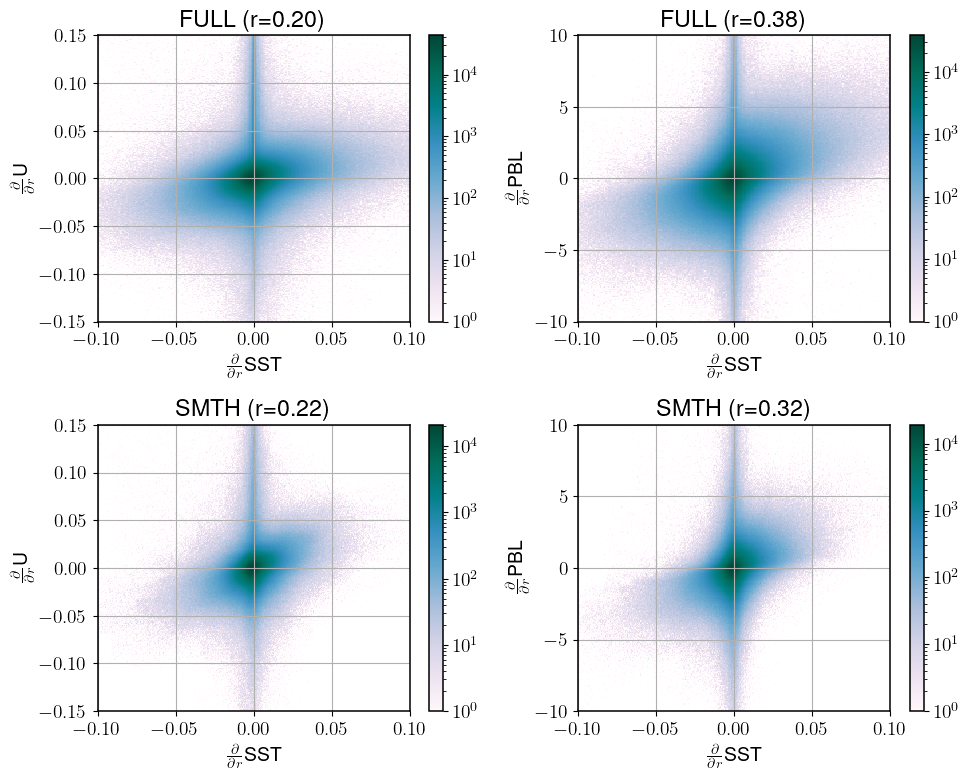

In [151]:
wdw=8

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.hist2d(np.ravel(dsst_dr_full.rolling(time_counter=wdw).mean().dropna('time_counter')),
           np.ravel(d_ur_dr_full.rolling(time_counter=wdw).mean().dropna('time_counter')),
           cmap='PuBuGn',norm=mpl.colors.LogNorm(),bins=1000)
plt.colorbar()
plt.title('FULL (r='+ '{0:.2f})'.format(
    np.corrcoef(np.ravel(dsst_dr_full.rolling(time_counter=wdw).mean().dropna('time_counter').values),
                np.ravel(d_ur_dr_full.rolling(time_counter=wdw).mean().dropna('time_counter').values))[0][1]))
plt.grid()
plt.xlabel(r'$\frac{\partial}{\partial r}$SST')
plt.ylabel(r'$\frac{\partial}{\partial r}$U')
plt.ylim(-0.15,0.15)
plt.xlim(-0.1,0.1)


plt.subplot(2,2,2)
plt.hist2d(np.ravel(dsst_dr_full.rolling(time_counter=wdw).mean().dropna('time_counter')),
           np.ravel(dpbl_dr_full.rolling(time_counter=wdw).mean().dropna('time_counter')),cmap='PuBuGn',norm=mpl.colors.LogNorm(),bins=1000)
plt.colorbar()
plt.title('FULL (r='+ '{0:.2f})'.format(
    np.corrcoef(np.ravel(dsst_dr_full.rolling(time_counter=wdw).mean().dropna('time_counter').values),
                np.ravel(dpbl_dr_full.rolling(time_counter=wdw).mean().dropna('time_counter').values))[0][1]))
plt.grid()
plt.xlabel(r'$\frac{\partial}{\partial r}$SST')
plt.ylabel(r'$\frac{\partial}{\partial r}$PBL')
plt.ylim(-10,10)
plt.xlim(-0.1,0.1)




plt.subplot(2,2,3)
plt.hist2d(np.ravel(dsst_dr_smth.rolling(time_counter=wdw).mean().dropna('time_counter')),
           np.ravel(d_ur_dr_smth.rolling(time_counter=wdw).mean().dropna('time_counter')),
           cmap='PuBuGn',norm=mpl.colors.LogNorm(),bins=1000)
plt.colorbar()
plt.title('SMTH (r='+ '{0:.2f})'.format(
    np.corrcoef(np.ravel(dsst_dr_smth.rolling(time_counter=wdw).mean().dropna('time_counter').values),
                np.ravel(d_ur_dr_smth.rolling(time_counter=wdw).mean().dropna('time_counter').values))[0][1]))
plt.grid()
plt.xlabel(r'$\frac{\partial}{\partial r}$SST')
plt.ylabel(r'$\frac{\partial}{\partial r}$U')
plt.ylim(-0.15,0.15)
plt.xlim(-0.1,0.1)


plt.subplot(2,2,4)
plt.hist2d(np.ravel(dsst_dr_smth.rolling(time_counter=wdw).mean().dropna('time_counter')),
           np.ravel(dpbl_dr_smth.rolling(time_counter=wdw).mean().dropna('time_counter')),cmap='PuBuGn',norm=mpl.colors.LogNorm(),bins=1000)
plt.colorbar()
plt.title('SMTH (r='+ '{0:.2f})'.format(
    np.corrcoef(np.ravel(dsst_dr_smth.rolling(time_counter=wdw).mean().dropna('time_counter').values),
                np.ravel(dpbl_dr_smth.rolling(time_counter=wdw).mean().dropna('time_counter').values))[0][1]))
plt.grid()
plt.xlabel(r'$\frac{\partial}{\partial r}$SST')
plt.ylabel(r'$\frac{\partial}{\partial r}$PBL')
plt.ylim(-10,10)
plt.xlim(-0.1,0.1)

plt.tight_layout()

## Averages

### Normal correlation

In [112]:
wfl=1/150

day_i=0
day_e=213
levm=0



# wfl=50


levm=0


wfl=1/(150)
sst_mean_full=sst_full.isel(time_counter=slice(day_i,day_e)).copy(data=
                            gaussian_filter(sst_full.isel(time_counter=slice(day_i,day_e)),sigma=1/(2*np.pi*wfl) ).data)

pbl_mean_full=pbl_full.isel(time_counter=slice(day_i,day_e)).copy(data=
                            gaussian_filter(pbl_full.isel(time_counter=slice(day_i,day_e)),sigma=1/(2*np.pi*wfl) ).data)

u_mean_full=u_full.isel(time_counter=slice(day_i,day_e),lev_M=levm).copy(data=
                            gaussian_filter(u_full.isel(time_counter=slice(day_i,day_e),lev_M=levm),sigma=1/(2*np.pi*wfl) ).data)

v_mean_full=v_full.isel(time_counter=slice(day_i,day_e),lev_M=levm).copy(data=
                            gaussian_filter(v_full.isel(time_counter=slice(day_i,day_e),lev_M=levm),sigma=1/(2*np.pi*wfl) ).data)


wind_mean_full=np.sqrt(u_mean_full**2 + v_mean_full.values**2)



sst_anom_full=sst_full.isel(time_counter=slice(day_i,day_e))-sst_mean_full
u_anom_full=u_full.isel(time_counter=slice(day_i,day_e),lev_M=levm)-u_mean_full
v_anom_full=v_full.isel(time_counter=slice(day_i,day_e),lev_M=levm)-v_mean_full

# wind_anom_full=np.sqrt(u_anom_full**2 + v_anom_full.values**2)

pbl_anom_full=pbl_full.isel(time_counter=slice(day_i,day_e)).copy(data=(pbl_full.isel(time_counter=slice(day_i,day_e))-pbl_mean_full.values))

wind_anom_full=np.sqrt(u_full.isel(time_counter=slice(day_i,day_e),lev_M=levm)**2 + u_full.isel(time_counter=slice(day_i,day_e),lev_M=levm)**2)- wind_mean_full

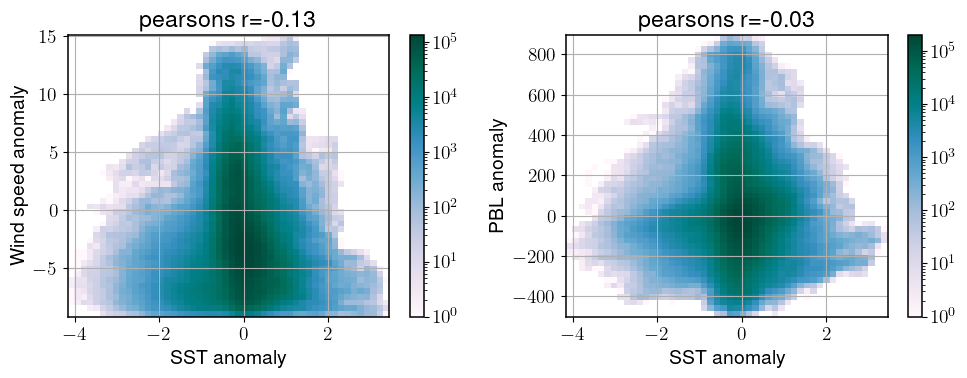

In [114]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)

plt.hist2d(np.ravel(sst_anom_full),np.ravel(wind_anom_full),cmap='PuBuGn',norm=mpl.colors.LogNorm(),bins=50)
plt.colorbar()
plt.title('pearsons r='+ '{0:.2f}'.format(np.corrcoef(np.ravel(sst_anom_full.values),np.ravel(wind_anom_full.values))[0][1]))
plt.grid()
plt.xlabel('SST anomaly')
plt.ylabel('Wind speed anomaly')
# plt.ylim(-1.5,1.5)
# plt.xlim(-0.5,0.5)

plt.subplot(1,2,2)
plt.hist2d(np.ravel(sst_anom_full),np.ravel(pbl_anom_full),cmap='PuBuGn',norm=mpl.colors.LogNorm(),bins=50)
plt.colorbar()
plt.title('pearsons r='+ '{0:.2f}'.format(np.corrcoef(np.ravel(sst_anom_full.values),
                                                      np.ravel(pbl_anom_full.values))[0][1]))
plt.grid()
plt.xlabel('SST anomaly')
plt.ylabel('PBL anomaly')
# plt.ylim(-1.5,1.5)
# plt.xlim(-0.5,0.5)
plt.tight_layout()


## Gradient method

In [115]:
ur_anom_full= u_anom_full.copy(data=((u_anom_full*(u_mean_full.values) + v_anom_full.values*(v_mean_full.values))/(wind_mean_full.values)))


In [117]:
dx=2
dy=2
dsst_dr_full = sst_anom_full.copy(data=
                                  along_wind_derivative(sst_anom_full.values,
                                dx=(dx),dy=(dy), #diff lon mean gives one value 
                                u_wind_ref=u_mean_full.values,
                                v_wind_ref=v_mean_full.values,
                                axis_x=2,axis_y=1))

d_ur_dr_full = ur_anom_full.copy(data=
                                 along_wind_derivative(ur_anom_full.values,
                                dx=(dx),dy=(dy),
                                u_wind_ref=u_mean_full.values,
                                v_wind_ref=v_mean_full.values,
                                axis_x=2,axis_y=1))

dpbl_dr_full = pbl_anom_full.copy(data=
                                  along_wind_derivative(pbl_anom_full.values,
                                dx=(dx),dy=(dy),
                                u_wind_ref=u_mean_full.values,
                                v_wind_ref=v_mean_full.values,
                                axis_x=2,axis_y=1))


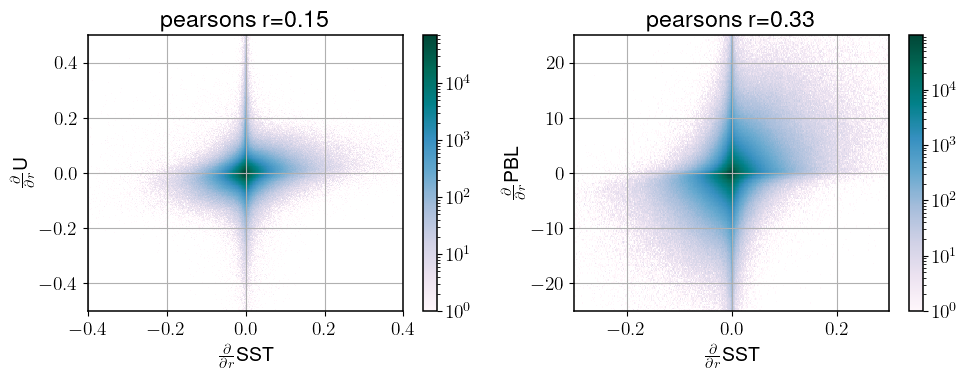

In [121]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist2d(np.ravel(dsst_dr_full),np.ravel(d_ur_dr_full),cmap='PuBuGn',norm=mpl.colors.LogNorm(),bins=1000)
plt.colorbar()
plt.title('pearsons r='+ '{0:.2f}'.format(
    np.corrcoef(np.ravel(dsst_dr_full.values),np.ravel(d_ur_dr_full.values))[0][1]))
plt.grid()
plt.xlabel(r'$\frac{\partial}{\partial r}$SST')
plt.ylabel(r'$\frac{\partial}{\partial r}$U')
plt.ylim(-0.5,0.5)
plt.xlim(-0.4,0.4)


plt.subplot(1,2,2)
plt.hist2d(np.ravel(dsst_dr_full),np.ravel(dpbl_dr_full),cmap='PuBuGn',norm=mpl.colors.LogNorm(),bins=1000)
plt.colorbar()
plt.title('pearsons r='+ '{0:.2f}'.format(
    np.corrcoef(np.ravel(dsst_dr_full.values),np.ravel(dpbl_dr_full.values))[0][1]))
plt.grid()
plt.xlabel(r'$\frac{\partial}{\partial r}$SST')
plt.ylabel(r'$\frac{\partial}{\partial r}$PBL')
plt.ylim(-25,25)
plt.xlim(-0.3,0.3)

plt.tight_layout()